In [1]:
import numpy as np 
import pandas as pd 
from pathlib import Path
import matplotlib.pyplot as plt 


In [2]:
# Class Label 


## Gene Present Absent 

In [3]:
gene_mult_0 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/gene_pa_output/gene_pa_merged_train/feature_selection/multisurf/multisurf_scores_cv_0.csv")
gene_mult_1 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/gene_pa_output/gene_pa_merged_train/feature_selection/multisurf/multisurf_scores_cv_1.csv")
gene_mult_2 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/gene_pa_output/gene_pa_merged_train/feature_selection/multisurf/multisurf_scores_cv_2.csv")


In [4]:
df_0 = pd.read_csv(gene_mult_0, skiprows=1, header = None, names = ['feature', 'score'])
df_1 = pd.read_csv(gene_mult_1,skiprows=1, header = None, names = ['feature', 'score'])
df_2 = pd.read_csv(gene_mult_2,skiprows=1, header = None, names = ['feature', 'score'])


In [5]:
df_0.head()


,feature,score
0,MAOGMHBA_01566_group_8265,0.424478
1,ECKICHIN_02367_bdcA,0.386414
2,ECKICHIN_02368_yjgH,0.385944
3,ECKICHIN_02360_group_26377,0.385581
4,FAHFDEJI_01305_group_4638,0.382750


In [6]:
df_1.head()


,feature,score
0,MAOGMHBA_01566_group_8265,0.396007
1,ECKICHIN_02368_yjgH,0.361473
2,ECKICHIN_02367_bdcA,0.359355
3,ECKICHIN_02365_tabA,0.358434
4,FAHFDEJI_01287_cybC,0.352620


In [7]:
# Merged on Feature 
merged_mult= df_0[['feature', 'score']].merge(
    df_1[['feature', 'score']], on='feature', suffixes=('_cv0', '_cv1')
).merge(
    df_2[['feature', 'score']], on='feature'
)
merged_mult.columns = ['feature', 'score_cv0', 'score_cv1', 'score_cv2']


In [8]:
merged_mult


,feature,score_cv0,score_cv1,score_cv2
0,MAOGMHBA_01566_group_8265,0.424478,0.396007,0.386635
1,ECKICHIN_02367_bdcA,0.386414,0.359355,0.348837
2,ECKICHIN_02368_yjgH,0.385944,0.361473,0.349685
3,ECKICHIN_02360_group_26377,0.385581,0.340670,0.329967
4,FAHFDEJI_01305_group_4638,0.382750,0.322287,0.348484
...,...,...,...,...
3077,FAHFDEJI_03315_group_23752,-0.057108,-0.046806,-0.027501
3078,FAHFDEJI_01753_ydjZ_2,-0.058121,-0.031191,-0.079780
3079,FAHFDEJI_02472_ftsY,-0.059540,-0.049868,-0.082023
3080,FAHFDEJI_01959_focC,-0.060578,-0.029345,-0.065081


In [9]:
# Step 4: Median across CVs
merged_mult['median_score'] = merged_mult[['score_cv0','score_cv1','score_cv2']].median(axis=1)


In [10]:
merged_mult


,feature,score_cv0,score_cv1,score_cv2,median_score
0,MAOGMHBA_01566_group_8265,0.424478,0.396007,0.386635,0.396007
1,ECKICHIN_02367_bdcA,0.386414,0.359355,0.348837,0.359355
2,ECKICHIN_02368_yjgH,0.385944,0.361473,0.349685,0.361473
3,ECKICHIN_02360_group_26377,0.385581,0.340670,0.329967,0.340670
4,FAHFDEJI_01305_group_4638,0.382750,0.322287,0.348484,0.348484
...,...,...,...,...,...
3077,FAHFDEJI_03315_group_23752,-0.057108,-0.046806,-0.027501,-0.046806
3078,FAHFDEJI_01753_ydjZ_2,-0.058121,-0.031191,-0.079780,-0.058121
3079,FAHFDEJI_02472_ftsY,-0.059540,-0.049868,-0.082023,-0.059540
3080,FAHFDEJI_01959_focC,-0.060578,-0.029345,-0.065081,-0.060578


### Mutual Information 

In [11]:
gene_MI = Path("/Users/921623492/Ecoli_Project/ML/Final_ML/Output_v3/Abdoul_thesis_ML_parallel/gene_pa_merged/feature_selection/mutual_information/mutual_information_scores_median_top50.csv")


In [12]:
df_MI= pd.read_csv(gene_MI)
df_MI.head()


,feature,median_score
0,MAOGMHBA_04933_group_2527,0.221579
1,GHHBFBJJ_04053_group_39082,0.215317
2,FAHFDEJI_01298_group_24131,0.209242
3,MAOGMHBA_04935_pemK,0.204193
4,FAHFDEJI_01297_argR_2,0.203049


In [13]:
top_n = 20 


In [14]:
mi_top = df_MI.sort_values('median_score', ascending=False).head(top_n).reset_index(drop=True)
multisurf_top = merged_mult.sort_values('median_score', ascending=False).head(top_n).reset_index(drop=True)


In [15]:
# Extract gene names (reuse your existing function)
def extract_gene_name(feature_name):
    parts = feature_name.split('_')
    if len(parts) >= 3 and parts[0].isalpha() and parts[1].isdigit():
        return '_'.join(parts[2:])
    return feature_name


In [16]:
mi_top['gene_name'] = mi_top['feature'].apply(extract_gene_name)
multisurf_top['gene_name'] = multisurf_top['feature'].apply(extract_gene_name)


In [17]:
mi_top.head()


,feature,median_score,gene_name
0,MAOGMHBA_04933_group_2527,0.221579,group_2527
1,GHHBFBJJ_04053_group_39082,0.215317,group_39082
2,FAHFDEJI_01298_group_24131,0.209242,group_24131
3,MAOGMHBA_04935_pemK,0.204193,pemK
4,FAHFDEJI_01297_argR_2,0.203049,argR_2


In [18]:
multisurf_top.head()


,feature,score_cv0,score_cv1,score_cv2,median_score,gene_name
0,MAOGMHBA_01566_group_8265,0.424478,0.396007,0.386635,0.396007,group_8265
1,FAHFDEJI_01287_cybC,0.382009,0.352620,0.388810,0.382009,cybC
2,FAHFDEJI_01302_tabA_2,0.375840,0.338711,0.371150,0.371150,tabA_2
3,FAHFDEJI_01299_argF,0.374044,0.328216,0.362429,0.362429,argF
4,FAHFDEJI_01298_group_24131,0.366276,0.321468,0.362429,0.362429,group_24131


In [19]:
# Finding overlapping genes 
overlap_genes = set(mi_top['gene_name']) & set(multisurf_top['gene_name'])


In [20]:
overlap_genes


{'arcA_2',
 'arcC1_3',
 'argF',
 'argI',
 'argR_2',
 'bdcA',
 'group_24131',
 'group_2537',
 'group_26113',
 'group_4638',
 'tabA',
 'tabA_2',
 'yjgH'}

In [21]:
# Colors 
COLOR_UNIQUE = '#2C5DAA' # blue for unique genes  
COLOR_OVERLAP = '#E8623A' # Orange for shared genes 
BGCOLOR = '#FAFBFF'


In [22]:
def get_colors(gene_series):
       return [COLOR_OVERLAP if g in overlap_genes else COLOR_UNIQUE for g in gene_series]


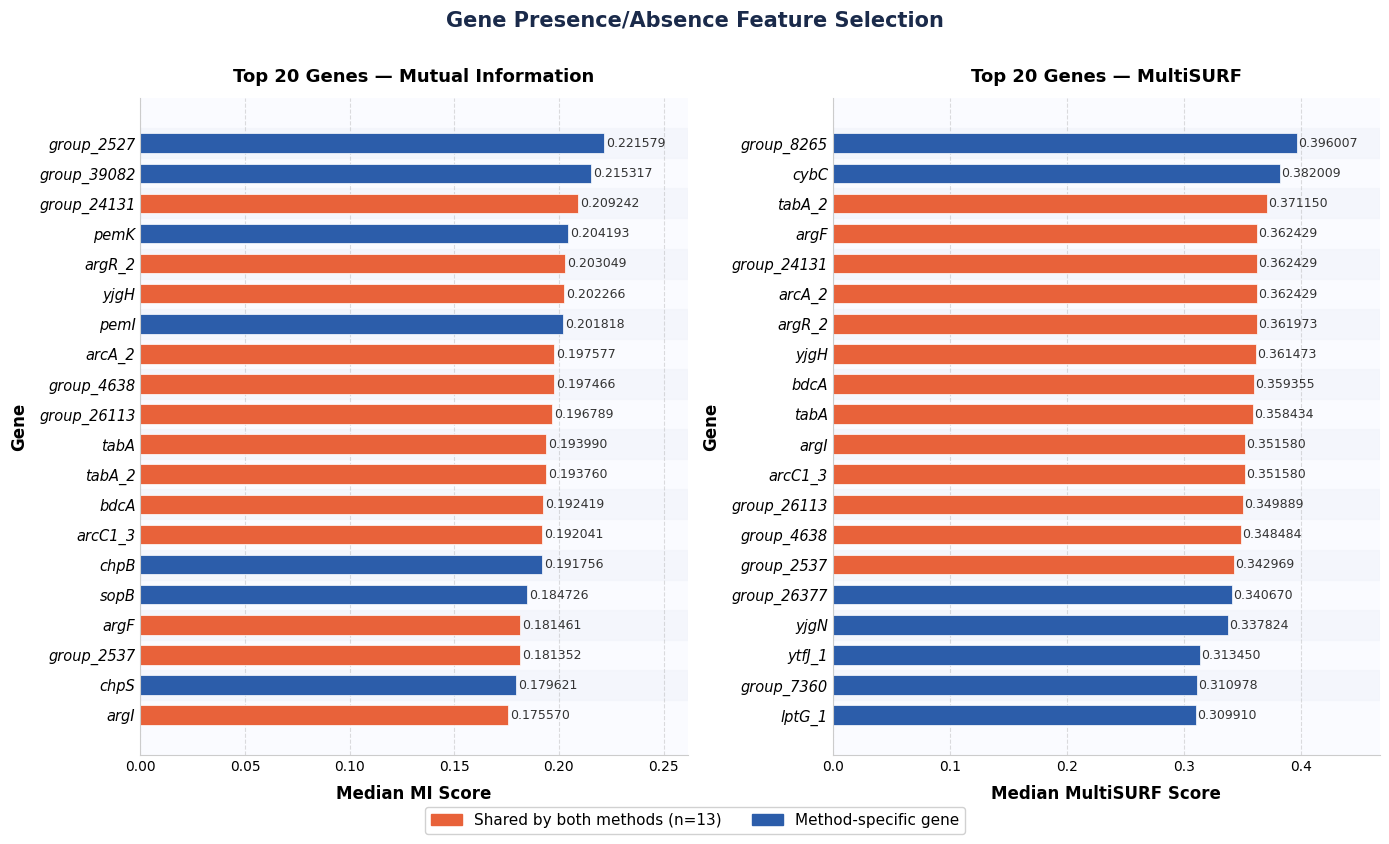


Overlapping genes (13): ['arcA_2', 'arcC1_3', 'argF', 'argI', 'argR_2', 'bdcA', 'group_24131', 'group_2537', 'group_26113', 'group_4638', 'tabA', 'tabA_2', 'yjgH']


In [23]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np



# ── FIGURE SETUP ──────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 8))
fig.patch.set_facecolor('white')

#Helper draw a panel 
def draw_panel(ax,df,title,xlabel):
       genes=df['gene_name']
       scores = df['median_score']
       colors = get_colors(genes)
       
       y_pos = range(len(df))
       bars = ax.barh(y_pos, scores, color=colors, height=0.65,
                     edgecolor='white', linewidth=0.5)
       
       # values labels 
       for i, (score, color) in enumerate(zip(scores, colors)):
              ax.text(score + 0.001, i, f"{score:3f}", 
              va='center', ha='left', fontsize=9,
              color='#333333', fontweight='normal')
       
       # Axis formatting
       ax.set_yticks(y_pos)
       ax.set_yticklabels(genes, fontsize=10.5, fontstyle='italic')
       ax.invert_yaxis()
       ax.set_xlabel(xlabel, fontsize=12, fontweight='bold', labelpad=8)
       ax.set_ylabel('Gene', fontsize=12, fontweight='bold', labelpad=8)
       ax.set_title(title, fontsize=13, fontweight='bold', pad=12)

       # Extend x-axis slightly for value labels
       ax.set_xlim(0, scores.max() * 1.18)

       # Grid & spines
       ax.grid(axis='x', linestyle='--', alpha=0.4, color='#aaaaaa')
       ax.set_axisbelow(True)
       ax.spines['top'].set_visible(False)
       ax.spines['right'].set_visible(False)
       ax.spines['left'].set_color('#cccccc')
       ax.spines['bottom'].set_color('#cccccc')
       ax.set_facecolor(BGCOLOR)
       ax.tick_params(axis='both', which='both', length=0)

       # Subtle alternating row shading
       for i in range(len(df)):
              if i % 2 == 0:
                     ax.axhspan(i - 0.5, i + 0.5, color='#f0f3fa', zorder=0, alpha=0.5)

draw_panel(axes[0], mi_top,
           'Top 20 Genes — Mutual Information',
           'Median MI Score')

draw_panel(axes[1], multisurf_top,
           'Top 20 Genes — MultiSURF',
           'Median MultiSURF Score')


#  SHARED LEGEND ─────────────────────────────────────────────────────────
n_overlap = len(overlap_genes)
patch_overlap = mpatches.Patch(color=COLOR_OVERLAP,
                               label=f'Shared by both methods (n={n_overlap})')
patch_unique  = mpatches.Patch(color=COLOR_UNIQUE,
                               label='Method-specific gene')

fig.legend(handles=[patch_overlap, patch_unique],
           loc='lower center', ncol=2,
           fontsize=11, frameon=True,
           framealpha=0.9, edgecolor='#cccccc',
           bbox_to_anchor=(0.5, -0.03))

plt.suptitle('Gene Presence/Absence Feature Selection',
             fontsize=15, fontweight='bold', y=1.01, color='#1a2a4a')

plt.tight_layout()
plt.savefig('/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/notebooks/gene_feature_selection.png',
            dpi=300, bbox_inches='tight',
            facecolor='white')
plt.show()
print(f"\nOverlapping genes ({n_overlap}): {sorted(overlap_genes)}")


## SNP Data 

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import numpy as np
from pathlib import Path


In [25]:
snp_0 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/snp/2025-12-24/snp_output/SNP_merged_train/feature_selection/mutual_information/mutual_information_scores_cv_0.csv")
snp_1 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/snp/2025-12-24/snp_output/SNP_merged_train/feature_selection/mutual_information/mutual_information_scores_cv_1.csv")
snp_2 = Path("/Users/921623492/Abdoul Thesis/Abdoul_project/results/snp/2025-12-24/snp_output/SNP_merged_train/feature_selection/mutual_information/mutual_information_scores_cv_2.csv")

snp_location = Path("/Users/921623492/Ecoli_Project/ML/Data/snp_locations.csv")
gene_coordinate = Path("/Users/921623492/Ecoli_Project/MAF/gene_coordinates.csv")


In [26]:
df_snp_location = pd.read_csv(snp_location)
df_snp_location.head()


,Unnamed: 0,CHR,POS,REF
0,SNP_0,FAHFDEJI_03109,132,C
1,SNP_1,FAHFDEJI_00069,45,C
2,SNP_2,FAHFDEJI_02554,186,A
3,SNP_3,FAHFDEJI_02554,195,T
4,SNP_4,FAHFDEJI_02554,333,T


In [27]:
df_gene_coordinate = pd.read_csv(gene_coordinate)
df_gene_coordinate.head()


,gene_id,gene_name,start,end,length
0,FAHFDEJI_03109,rpmG,0,168,168
1,FAHFDEJI_02987,atpE,168,408,240
2,FAHFDEJI_00069,gnsA,408,582,174
3,FAHFDEJI_01249,rpsR,582,810,228
4,FAHFDEJI_02554,fnr,810,1563,753


In [28]:
# step 1: Annotate all SNPs with gene names 
merged_all = df_snp_location.merge(df_gene_coordinate, left_on='CHR', right_on='gene_id', how='left')


In [29]:
merged_all.head()


,Unnamed: 0,CHR,POS,REF,gene_id,gene_name,start,end,length
0,SNP_0,FAHFDEJI_03109,132,C,FAHFDEJI_03109,rpmG,0,168,168
1,SNP_1,FAHFDEJI_00069,45,C,FAHFDEJI_00069,gnsA,408,582,174
2,SNP_2,FAHFDEJI_02554,186,A,FAHFDEJI_02554,fnr,810,1563,753
3,SNP_3,FAHFDEJI_02554,195,T,FAHFDEJI_02554,fnr,810,1563,753
4,SNP_4,FAHFDEJI_02554,333,T,FAHFDEJI_02554,fnr,810,1563,753


## SNPs 

In [30]:
df_snp_0 = pd.read_csv(snp_0, skiprows=1, header=None, names = ['feature', 'score'])
df_snp_1 = pd.read_csv(snp_1,skiprows=1, header=None, names = ['feature', 'score'])
df_snp_2 = pd.read_csv(snp_2,skiprows=1, header=None, names = ['feature', 'score'])


In [31]:
df_snp_0


,feature,score
0,SNP_17651,0.548810
1,SNP_12955_1,0.527269
2,SNP_12955_0,0.493377
3,SNP_10068,0.267196
4,SNP_6421,0.260930
...,...,...
67254,SNP_56699_1,0.000000
67255,SNP_56699_2,0.000000
67256,SNP_56700_1,0.000000
67257,SNP_56700_2,0.000000


In [32]:
# Merged on Feature 
merged_snp= df_snp_0[['feature', 'score']].merge(
    df_snp_1[['feature', 'score']], on='feature', suffixes=('_cv0', '_cv1')
).merge(
    df_snp_2[['feature', 'score']], on='feature'
)
merged_snp.columns = ['feature', 'score_cv0', 'score_cv1', 'score_cv2']


In [33]:
merged_snp


,feature,score_cv0,score_cv1,score_cv2
0,SNP_17651,0.548810,0.562826,0.533728
1,SNP_12955_1,0.527269,0.567524,0.548330
2,SNP_12955_0,0.493377,0.527646,0.539245
3,SNP_10068,0.267196,0.160860,0.171619
4,SNP_6421,0.260930,0.211004,0.209065
...,...,...,...,...
67254,SNP_56699_1,0.000000,0.000000,0.044755
67255,SNP_56699_2,0.000000,0.019514,0.000000
67256,SNP_56700_1,0.000000,0.000000,0.000000
67257,SNP_56700_2,0.000000,0.018139,0.000000


In [34]:
merged_snp['median_score'] = merged_snp[['score_cv0','score_cv1','score_cv2']].median(axis=1)


In [35]:
merged_snp


,feature,score_cv0,score_cv1,score_cv2,median_score
0,SNP_17651,0.548810,0.562826,0.533728,0.548810
1,SNP_12955_1,0.527269,0.567524,0.548330,0.548330
2,SNP_12955_0,0.493377,0.527646,0.539245,0.527646
3,SNP_10068,0.267196,0.160860,0.171619,0.171619
4,SNP_6421,0.260930,0.211004,0.209065,0.211004
...,...,...,...,...,...
67254,SNP_56699_1,0.000000,0.000000,0.044755,0.000000
67255,SNP_56699_2,0.000000,0.019514,0.000000,0.000000
67256,SNP_56700_1,0.000000,0.000000,0.000000,0.000000
67257,SNP_56700_2,0.000000,0.018139,0.000000,0.000000


In [36]:
# Step 1: Clean up merged_all to get snp_id and gene_name
snp_annotated = merged_all[['Unnamed: 0', 'CHR', 'POS', 'REF', 'gene_name']].copy()
snp_annotated.rename(columns={'Unnamed: 0': 'snp_id'}, inplace=True)


In [37]:
def get_snp_base(feature):
    parts = feature.rsplit('_', 1)  # remove the n= keyword
    if parts[-1] in ['0', '1', '2', '3']:
        return parts[0]
    else:
        return feature

merged_snp['snp_base'] = merged_snp['feature'].apply(get_snp_base)

# Verify it looks correct
print(merged_snp[['feature', 'snp_base']].head(20))


        feature   snp_base
0     SNP_17651  SNP_17651
1   SNP_12955_1  SNP_12955
2   SNP_12955_0  SNP_12955
3     SNP_10068  SNP_10068
4      SNP_6421   SNP_6421
5    SNP_7709_0   SNP_7709
6   SNP_45484_2  SNP_45484
7     SNP_25744  SNP_25744
8   SNP_17653_2  SNP_17653
9     SNP_27835  SNP_27835
10  SNP_30628_2  SNP_30628
11    SNP_33827  SNP_33827
12    SNP_32465  SNP_32465
13    SNP_43207  SNP_43207
14    SNP_34873  SNP_34873
15    SNP_14115  SNP_14115
16     SNP_1001   SNP_1001
17  SNP_39741_2  SNP_39741
18      SNP_293    SNP_293
19    SNP_30984  SNP_30984


In [38]:
# Step 2: Join with your MI scores
# First extract the base SNP id from feature (SNP_12955_1 -> SNP_12955)
# merged_snp['snp_base'] = merged_snp['feature'].str.rsplit('_', n=1).str[0]

merged_snp_annotated = merged_snp.merge(
    snp_annotated[['snp_id', 'gene_name']],
    left_on='snp_base',
    right_on='snp_id',
    how='left'
)

# Step 3: Create display label — gene name + feature for clarity
merged_snp_annotated['display_label'] = (
    merged_snp_annotated['gene_name'].fillna('intergenic') + 
    ' (' + merged_snp_annotated['feature'] + ')'
)

print(merged_snp_annotated[['feature', 'snp_base', 'gene_name', 
                              'display_label', 'median_score']].head(10))


       feature   snp_base gene_name        display_label  median_score
0    SNP_17651  SNP_17651      parC     parC (SNP_17651)      0.548810
1  SNP_12955_1  SNP_12955      gyrA   gyrA (SNP_12955_1)      0.548330
2  SNP_12955_0  SNP_12955      gyrA   gyrA (SNP_12955_0)      0.527646
3    SNP_10068  SNP_10068      recF     recF (SNP_10068)      0.171619
4     SNP_6421   SNP_6421      gcvP      gcvP (SNP_6421)      0.211004
5   SNP_7709_0   SNP_7709    fdoG_1  fdoG_1 (SNP_7709_0)      0.221395
6  SNP_45484_2  SNP_45484      mgtA   mgtA (SNP_45484_2)      0.252329
7    SNP_25744  SNP_25744      lpoA     lpoA (SNP_25744)      0.244082
8  SNP_17653_2  SNP_17653      parC   parC (SNP_17653_2)      0.211689
9    SNP_27835  SNP_27835      nupC     nupC (SNP_27835)      0.211821


In [39]:
top_n = 20


In [40]:
top_snp = merged_snp_annotated.sort_values('median_score', ascending=False).head(top_n).reset_index(drop=True)


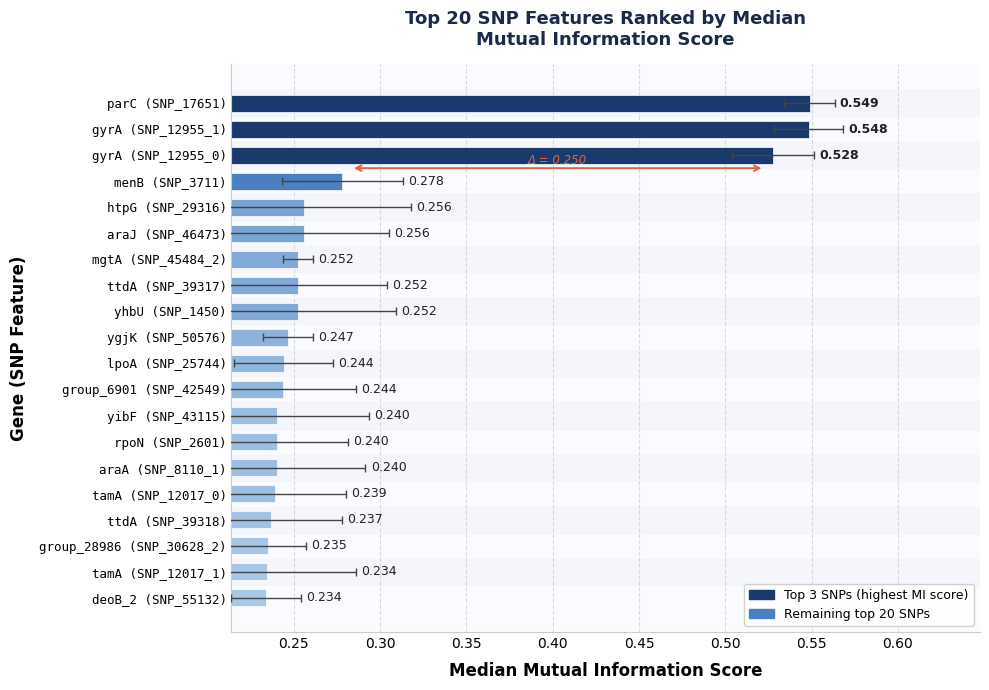


Top 3 SNPs:
  parC (SNP_17651): 0.549 (±0.015)
  gyrA (SNP_12955_1): 0.548 (±0.020)
  gyrA (SNP_12955_0): 0.528 (±0.024)

Score gap between rank 3 and rank 4: 0.250


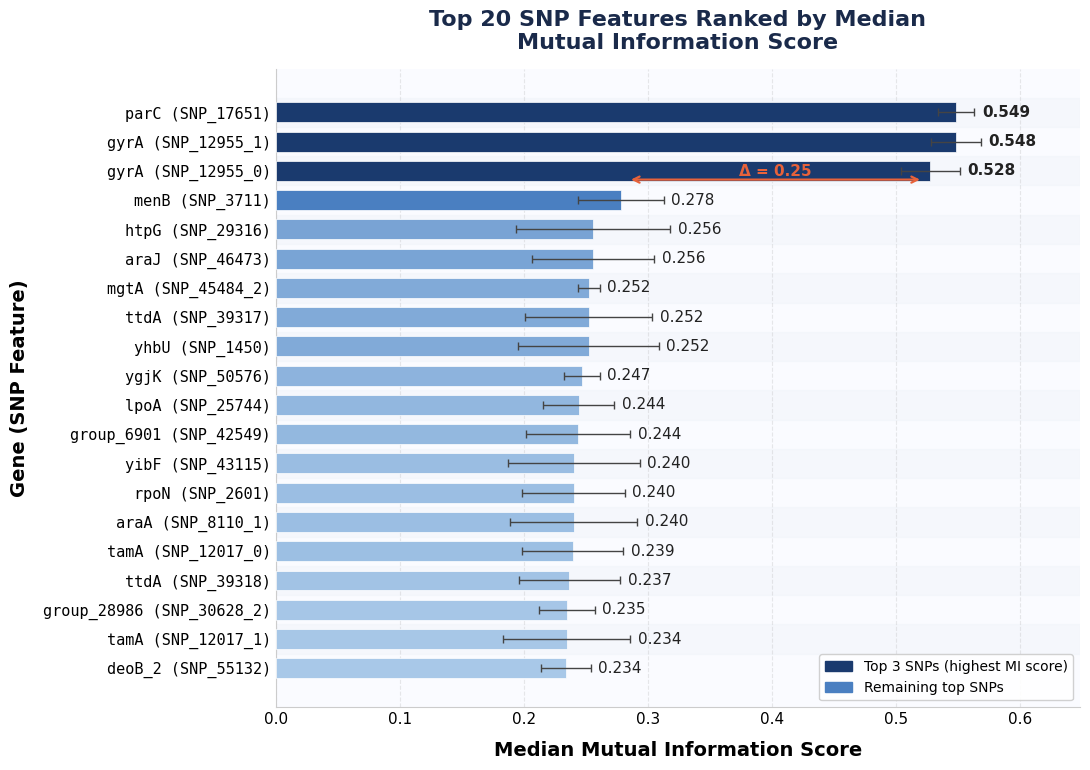


Top 3 SNPs:
  parC (SNP_17651): 0.549 (±0.015)
  gyrA (SNP_12955_1): 0.548 (±0.020)
  gyrA (SNP_12955_0): 0.528 (±0.024)

Score gap between rank 3 and rank 4: 0.250


In [43]:
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── PARAMETERS ────────────────────────────────────────────────────────────
top_n = 20

# Use annotated SNP table
top_snp = (
    merged_snp_annotated
    .sort_values('median_score', ascending=False)
    .head(top_n)
    .reset_index(drop=True)
)

# ── COLORS ────────────────────────────────────────────────────────────────
TOP3_COLOR = "#1a3a6e"
GRAD_HIGH  = "#4a7fc1"
GRAD_LOW   = "#a8c8e8"

def get_color(i, score, scores):
    if i < 3:
        return TOP3_COLOR
    rest_scores = scores[3:]
    norm = (score - rest_scores.min()) / (rest_scores.max() - rest_scores.min() + 1e-9)

    r1, g1, b1 = 0xa8/255, 0xc8/255, 0xe8/255
    r2, g2, b2 = 0x4a/255, 0x7f/255, 0xc1/255
    return (
        r1 + norm * (r2 - r1),
        g1 + norm * (g2 - g1),
        b1 + norm * (b2 - b1)
    )

scores_arr = top_snp['median_score'].values
colors = [get_color(i, scores_arr[i], scores_arr) for i in range(top_n)]

# ── FIGURE ────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 7.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('#FAFBFF')

y_pos_snp = np.arange(top_n)

# Alternating row shading
for i in range(top_n):
    if i % 2 == 0:
        ax.axhspan(i - 0.5, i + 0.5, color='#f0f3fa', zorder=0, alpha=0.45)

# Bars
ax.barh(
    y_pos_snp,
    top_snp['median_score'],
    color=colors,
    height=0.68,
    edgecolor='white',
    linewidth=0.5,
    zorder=3
)

# ── ERROR BARS ────────────────────────────────────────────────────────────
cv_cols = ['score_cv0', 'score_cv1', 'score_cv2']
xerr = top_snp[cv_cols].std(axis=1)

ax.errorbar(
    top_snp['median_score'],
    y_pos_snp,
    xerr=xerr,
    fmt='none',
    ecolor='#444444',
    elinewidth=1.0,
    capsize=3,
    capthick=1.0,
    zorder=5
)

# ── VALUE LABELS ──────────────────────────────────────────────────────────
for i, (score, err) in enumerate(zip(top_snp['median_score'], xerr)):
    ax.text(
        score + err + 0.006,
        i,
        f"{score:.3f}",
        va='center',
        ha='left',
        fontsize=11,
        color='#222222',
        fontweight='bold' if i < 3 else 'normal'
    )

# ── GAP ANNOTATION between rank 3 and rank 4 ─────────────────────────────
gap_y   = 2.3
score_3 = scores_arr[2]
score_4 = scores_arr[3]

ax.annotate(
    '',
    xy=(score_4 + 0.006, gap_y),
    xytext=(score_3 - 0.006, gap_y),
    arrowprops=dict(
        arrowstyle='<->',
        color='#E8623A',
        lw=1.6,
        mutation_scale=11
    )
)

ax.text(
    (score_3 + score_4) / 2,
    gap_y - 0.55,
    f'Δ = {score_3 - score_4:.2f}',
    ha='center',
    va='top',
    fontsize=11,
    color='#E8623A',
    fontweight='bold'
)

# ── AXIS FORMATTING ───────────────────────────────────────────────────────
ax.set_yticks(y_pos_snp)
ax.set_yticklabels(
    top_snp['display_label'],
    fontsize=11,
    fontfamily='monospace'
)
ax.invert_yaxis()

# Start x-axis from 0, as your professor suggested
x_max = (top_snp['median_score'] + xerr).max()
ax.set_xlim(0, x_max + 0.08)

ax.set_xlabel(
    'Median Mutual Information Score',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)
ax.set_ylabel(
    'Gene (SNP Feature)',
    fontsize=14,
    fontweight='bold',
    labelpad=10
)
ax.set_title(
    'Top 20 SNP Features Ranked by Median\nMutual Information Score',
    fontsize=16,
    fontweight='bold',
    pad=14,
    color='#1a2a4a'
)

ax.grid(axis='x', linestyle='--', alpha=0.25, color='#aaaaaa')
ax.set_axisbelow(True)

ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_color('#cccccc')
ax.spines['bottom'].set_color('#cccccc')

ax.tick_params(axis='x', labelsize=11, length=0)
ax.tick_params(axis='y', length=0)

# ── LEGEND ────────────────────────────────────────────────────────────────
patch_top  = mpatches.Patch(color=TOP3_COLOR, label='Top 3 SNPs (highest MI score)')
patch_rest = mpatches.Patch(color=GRAD_HIGH, label='Remaining top SNPs')

ax.legend(
    handles=[patch_top, patch_rest],
    loc='lower right',
    fontsize=10,
    frameon=True,
    framealpha=0.9,
    edgecolor='#cccccc'
)

plt.tight_layout()
plt.savefig(
    '/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/notebooks/Top_SNP_Feature2_updated.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white'
)
plt.show()

print("\nTop 3 SNPs:")
for i in range(3):
    print(f"  {top_snp['display_label'].iloc[i]}: {scores_arr[i]:.3f} (±{xerr.iloc[i]:.3f})")

print(f"\nScore gap between rank 3 and rank 4: {scores_arr[2] - scores_arr[3]:.3f}")


## Box Plots 

In [ ]:
def metric_boxplots(self, metrics, metric_dict):
    """
    Export boxplots comparing algorithm performance for each metric.
    """
    import os
    import pandas as pd
    import matplotlib.pyplot as plt

    outdir = os.path.join(self.full_path, 'model_evaluation', 'metricBoxplots')
    os.makedirs(outdir, exist_ok=True)

    # Optional: shorter names improve readability
    display_names = {
        'Decision Tree': 'DT',
        'Extreme Gradient Boosting': 'XGB',
        'K-Nearest Neighbors': 'KNN',
        'Logistic Regression': 'LR',
        'Random Forest': 'RF'
    }

    for metric in metrics:
        temp_list = []
        col_names = []

        for algorithm in self.algorithms:
            temp_list.append(metric_dict[algorithm][metric])
            col_names.append(display_names.get(algorithm, algorithm))

        td = pd.DataFrame(temp_list).transpose().astype(float)
        td.columns = col_names

        fig, ax = plt.subplots(figsize=(6, 5.5))

        td.plot(
            kind='box',
            ax=ax,
            rot=45,
            fontsize=11,
            grid=True
        )

        ax.set_ylabel(str(metric), fontsize=13, fontweight='bold')
        ax.set_xlabel('')  # remove repeated x-axis label
        ax.set_title(str(metric), fontsize=14, fontweight='bold', pad=10)

        # Improve tick label readability
        ax.tick_params(axis='x', labelsize=11)
        ax.tick_params(axis='y', labelsize=11)
        plt.setp(ax.get_xticklabels(), ha='right')

        # Cleaner grid
        ax.grid(axis='y', linestyle='--', alpha=0.3)

        # Tight layout before saving
        fig.tight_layout()

        safe_metric = metric.replace(' ', '_').replace('/', '_')
        fig.savefig(
            os.path.join(outdir, f'Compare_{safe_metric}.png'),
            dpi=300,
            bbox_inches='tight'
        )
        plt.close(fig)


In [2]:
from pathlib import Path
import os
import pandas as pd
import matplotlib.pyplot as plt


def metric_boxplots(self, metrics, metric_dict):
    """
    Export boxplots comparing algorithm performance for each metric.
    """
    outdir = os.path.join(self.full_path, "model_evaluation", "metricBoxplots")
    os.makedirs(outdir, exist_ok=True)

    display_names = {
        "Decision Tree": "DT",
        "Extreme Gradient Boosting": "XGB",
        "K-Nearest Neighbors": "KNN",
        "Logistic Regression": "LR",
        "Random Forest": "RF",
    }

    for metric in metrics:
        temp_list = []
        col_names = []

        for algorithm in self.algorithms:
            temp_list.append(metric_dict[algorithm][metric])
            col_names.append(display_names.get(algorithm, algorithm))

        td = pd.DataFrame(temp_list).transpose().astype(float)
        td.columns = col_names

        fig, ax = plt.subplots(figsize=(6, 5.5))

        td.plot(
            kind="box",
            ax=ax,
            rot=45,
            fontsize=11,
            grid=True,
        )

        ax.set_ylabel(str(metric), fontsize=13, fontweight="bold")
        ax.set_xlabel("")
        ax.set_title(str(metric), fontsize=14, fontweight="bold", pad=10)

        ax.tick_params(axis="x", labelsize=11)
        ax.tick_params(axis="y", labelsize=11)
        plt.setp(ax.get_xticklabels(), ha="right")

        ax.grid(axis="y", linestyle="--", alpha=0.3)

        fig.tight_layout()

        safe_metric = metric.replace(" ", "_").replace("/", "_")
        fig.savefig(
            os.path.join(outdir, f"Compare_{safe_metric}.png"),
            dpi=300,
            bbox_inches="tight",
        )
        plt.close(fig)


# --- paths: point to the dataset folder that contains model_evaluation/ ---
FULL_PATH = Path(
    "/Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/"
    "gene_pa_output/gene_pa_merged_train/replication/gene_pa_merged_test"
)

# CSV column names must match STREAMLINE outputs (space in "ROC AUC", not "ROC-AUC")
METRICS_TO_PLOT = ["Balanced Accuracy", "F1 Score", "ROC AUC"]

# Abbrev in filenames (KNN_performance.csv) -> full STREAMLINE algorithm names (keys in metric_dict)
SHORT_TO_FULL = {
    "DT": "Decision Tree",
    "XGB": "Extreme Gradient Boosting",
    "KNN": "K-Nearest Neighbors",
    "LR": "Logistic Regression",
    "RF": "Random Forest",
}


def load_metric_dict_from_performance_csvs(model_eval_dir: Path) -> tuple[list[str], dict]:
    """Build metric_dict like STREAMLINE: algorithm -> {metric_name -> [cv0, cv1, ...]}."""
    metric_dict = {}
    paths = sorted(model_eval_dir.glob("*_performance.csv"))
    if not paths:
        raise FileNotFoundError(f"No *_performance.csv under {model_eval_dir}")

    algorithms = []
    for path in paths:
        short = path.name.replace("_performance.csv", "")
        if short not in SHORT_TO_FULL:
            raise KeyError(
                f"Unknown algorithm abbrev {short!r} from {path.name}. "
                f"Add it to SHORT_TO_FULL."
            )
        full = SHORT_TO_FULL[short]
        df = pd.read_csv(path)
        metric_dict[full] = {col: df[col].astype(float).tolist() for col in df.columns}
        algorithms.append(full)

    return algorithms, metric_dict


class BoxplotConfig:
    """Minimal stand-in for `self` in metric_boxplots(...)."""

    def __init__(self, full_path: Path, algorithms: list[str]):
        self.full_path = str(full_path)
        self.algorithms = algorithms


model_eval = FULL_PATH / "model_evaluation"
algorithms, metric_dict = load_metric_dict_from_performance_csvs(model_eval)

# Optional: same order as Summary_performance_mean.csv (first column)
summary = model_eval / "Summary_performance_mean.csv"
if summary.exists():
    order = pd.read_csv(summary, index_col=0).index.tolist()
    algorithms = [a for a in order if a in metric_dict]

cfg = BoxplotConfig(FULL_PATH, algorithms)
metric_boxplots(cfg, METRICS_TO_PLOT, metric_dict)

print("Wrote:", FULL_PATH / "model_evaluation" / "metricBoxplots")
for m in METRICS_TO_PLOT:
    safe = m.replace(" ", "_").replace("/", "_")
    print(" ", f"Compare_{safe}.png")


Wrote: /Users/921623492/Abdoul Thesis/Abdoul_project/results/gene_pa/2025-12-24/gene_pa_output/gene_pa_merged_train/replication/gene_pa_merged_test/model_evaluation/metricBoxplots
  Compare_Balanced_Accuracy.png
  Compare_F1_Score.png
  Compare_ROC_AUC.png
